In [17]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, facecolor='white')

print("Scanpy version:", sc.__version__)

Scanpy version: 1.12.3


C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_18684\1996363435.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [18]:
import scanpy as sc

data_path = r'C:\Users\Asrefanavary\melanoma-scrna-analysis\data\sample_02'

adata = sc.read_10x_mtx(
    data_path,
    var_names='gene_symbols',
    cache=False,
    compressed=False
)

adata.var_names_make_unique()

print(adata)

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
AnnData object with n_obs × n_vars = 10364 × 33538
    var: 'gene_ids', 'feature_types'
    layers: None (.X)


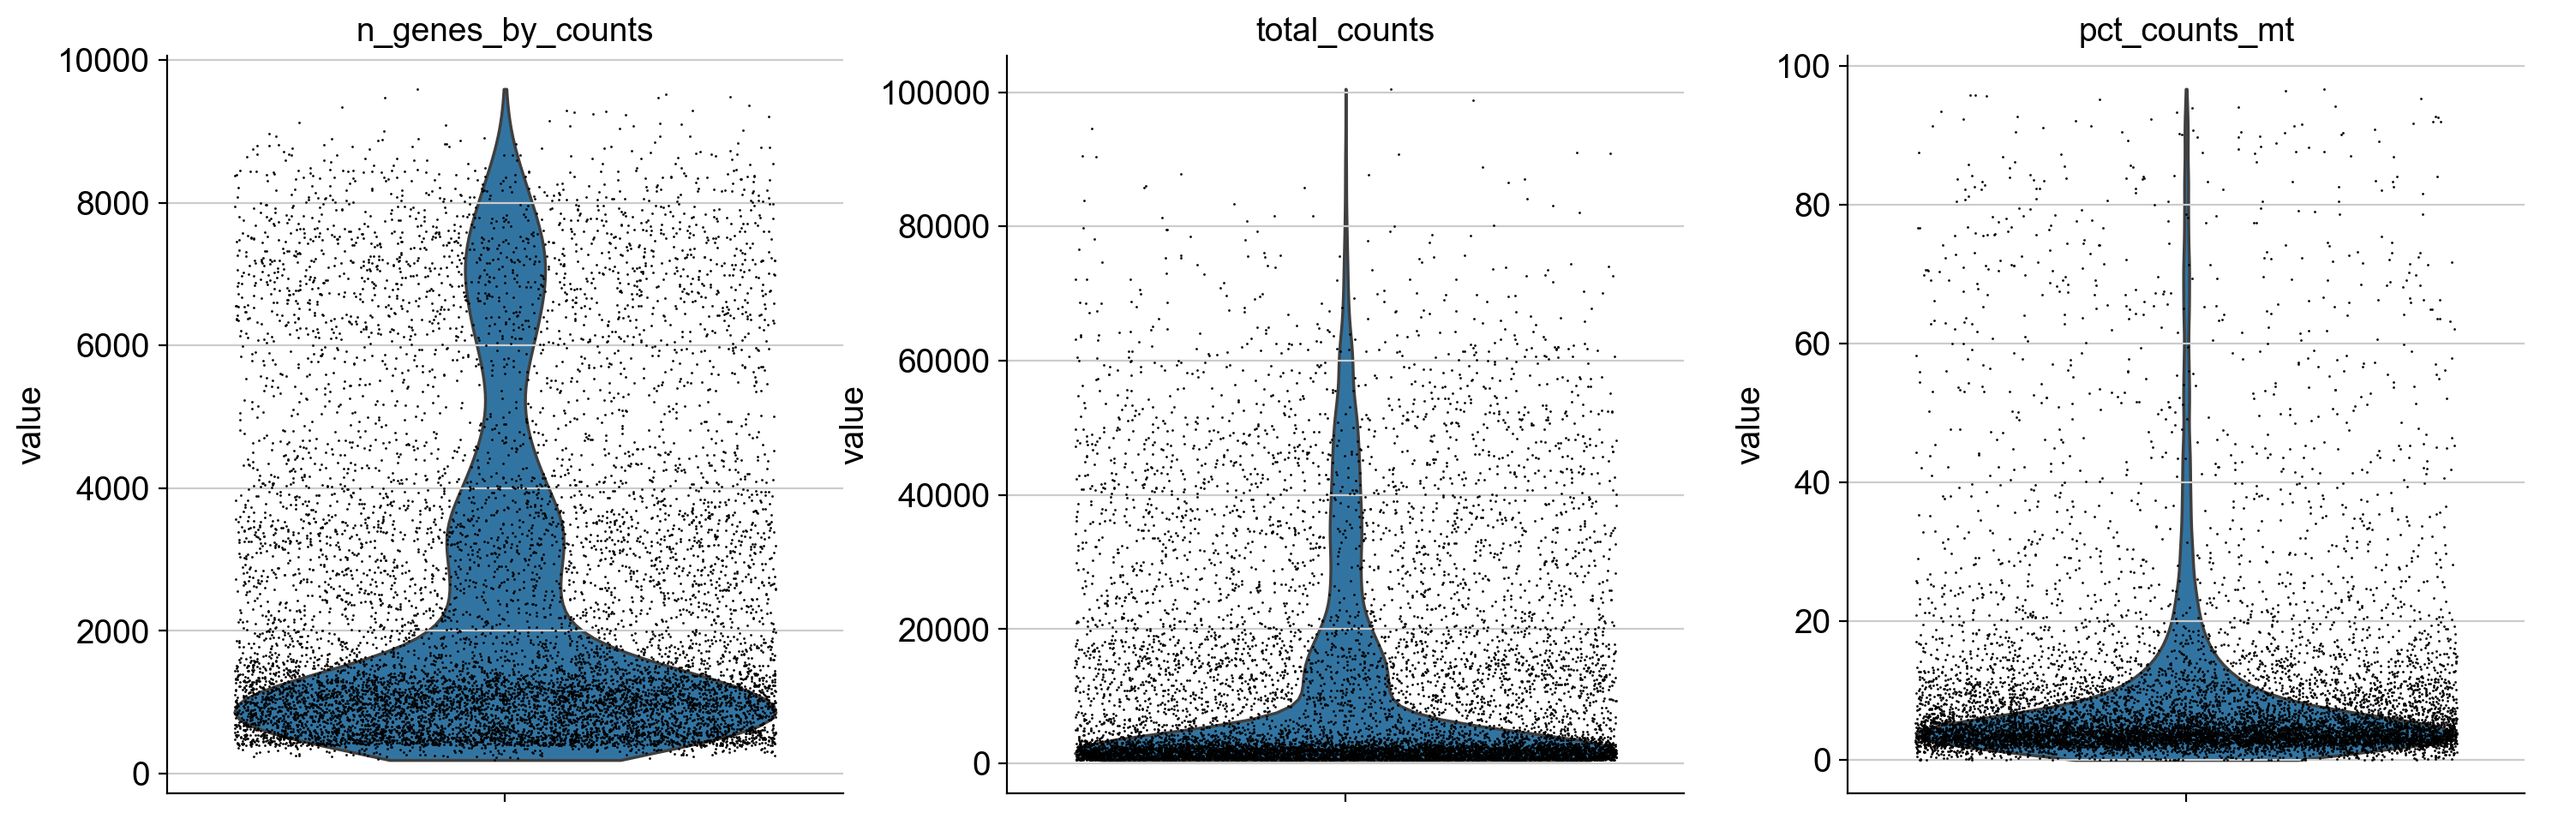

In [19]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [20]:
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.n_genes_by_counts < 5000, :]
adata = adata[adata.obs.pct_counts_mt < 15, :]

sc.pp.filter_genes(adata, min_cells=3)

print("Number of retained viable cells:", adata.n_obs)

filtered out 13659 genes that are detected in less than 3 cells


c:\Users\Asrefanavary\anaconda3\Lib\site-packages\scanpy\preprocessing\_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Number of retained viable cells: 7613


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


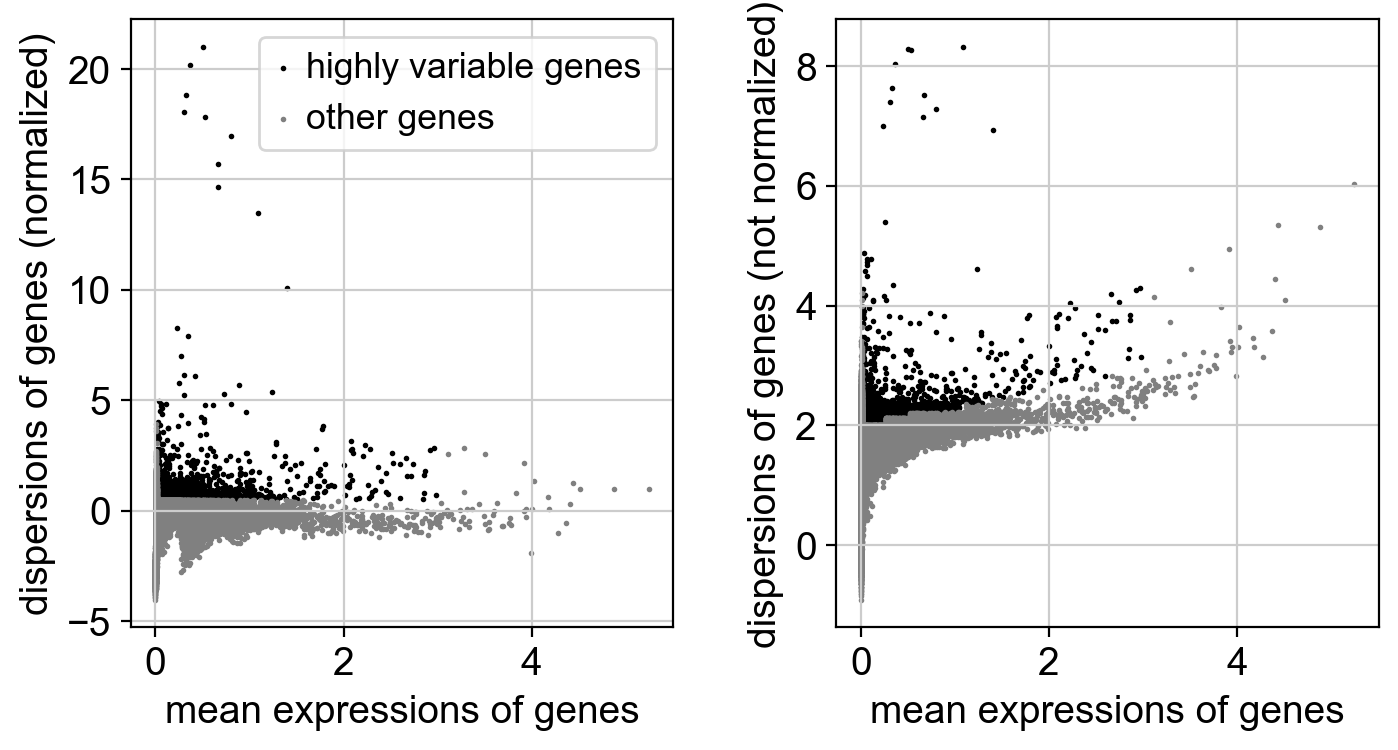

In [21]:
adata.raw = adata

sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

sc.pl.highly_variable_genes(adata)

c:\Users\Asrefanavary\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:21)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering


C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_18684\2642669143.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:19)


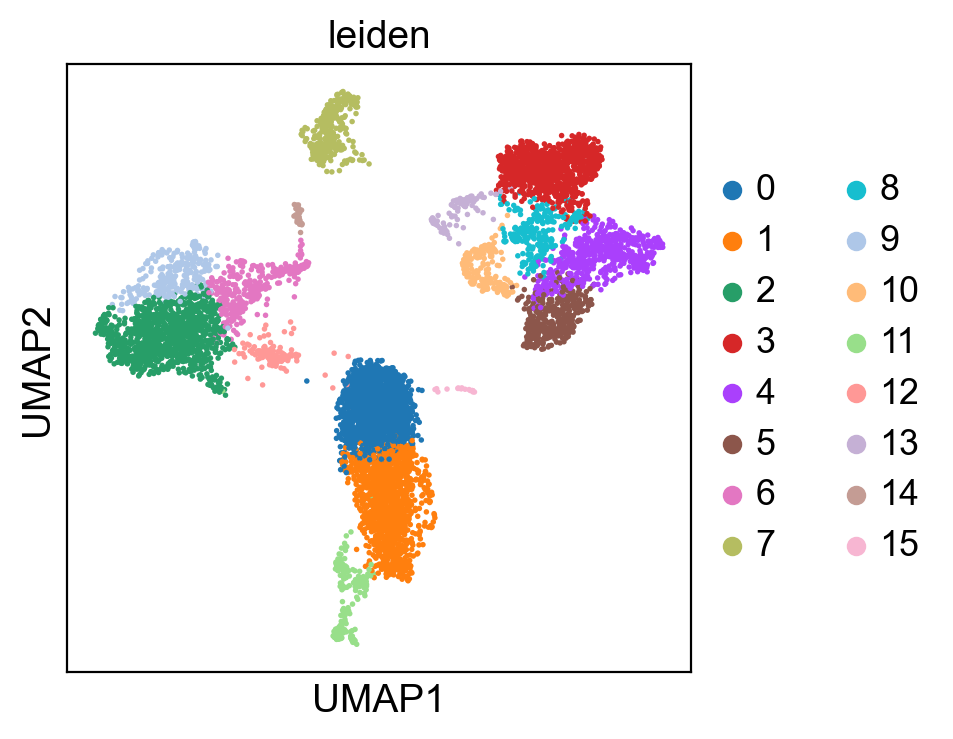

In [22]:
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack')

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)

sc.tl.leiden(adata)

sc.tl.umap(adata)

sc.pl.umap(adata, color=['leiden'])

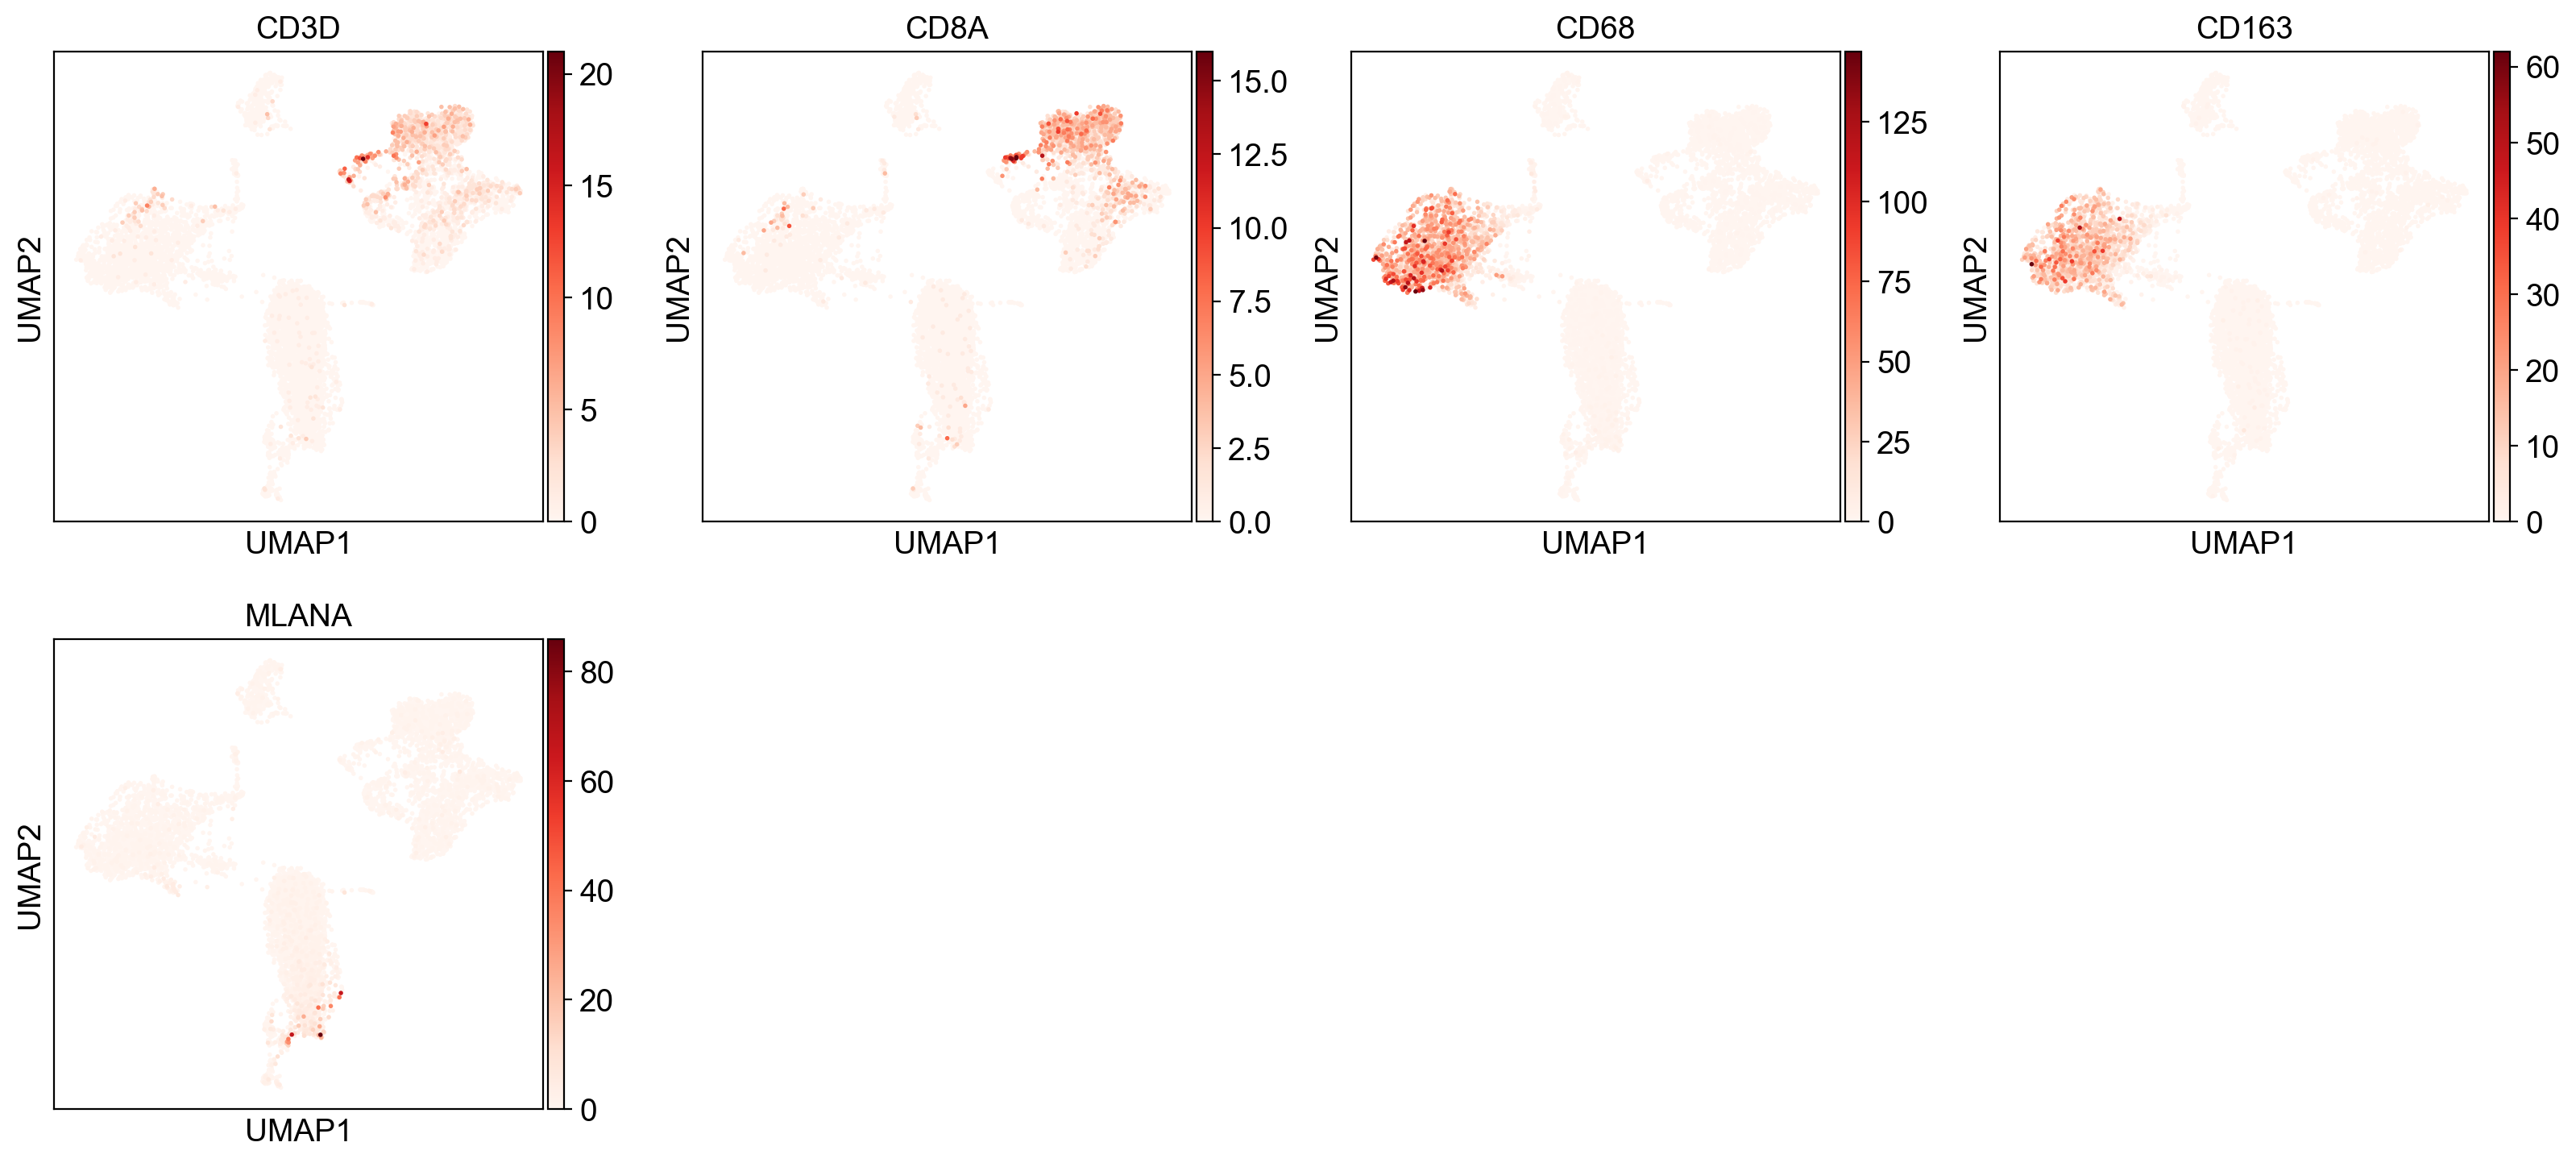

In [23]:
marker_genes = ['CD3D', 'CD8A', 'CD68', 'CD163', 'MLANA']

available_markers = [gene for gene in marker_genes if gene in adata.raw.var_names]

sc.pl.umap(adata, color=available_markers, color_map='Reds', use_raw=True)

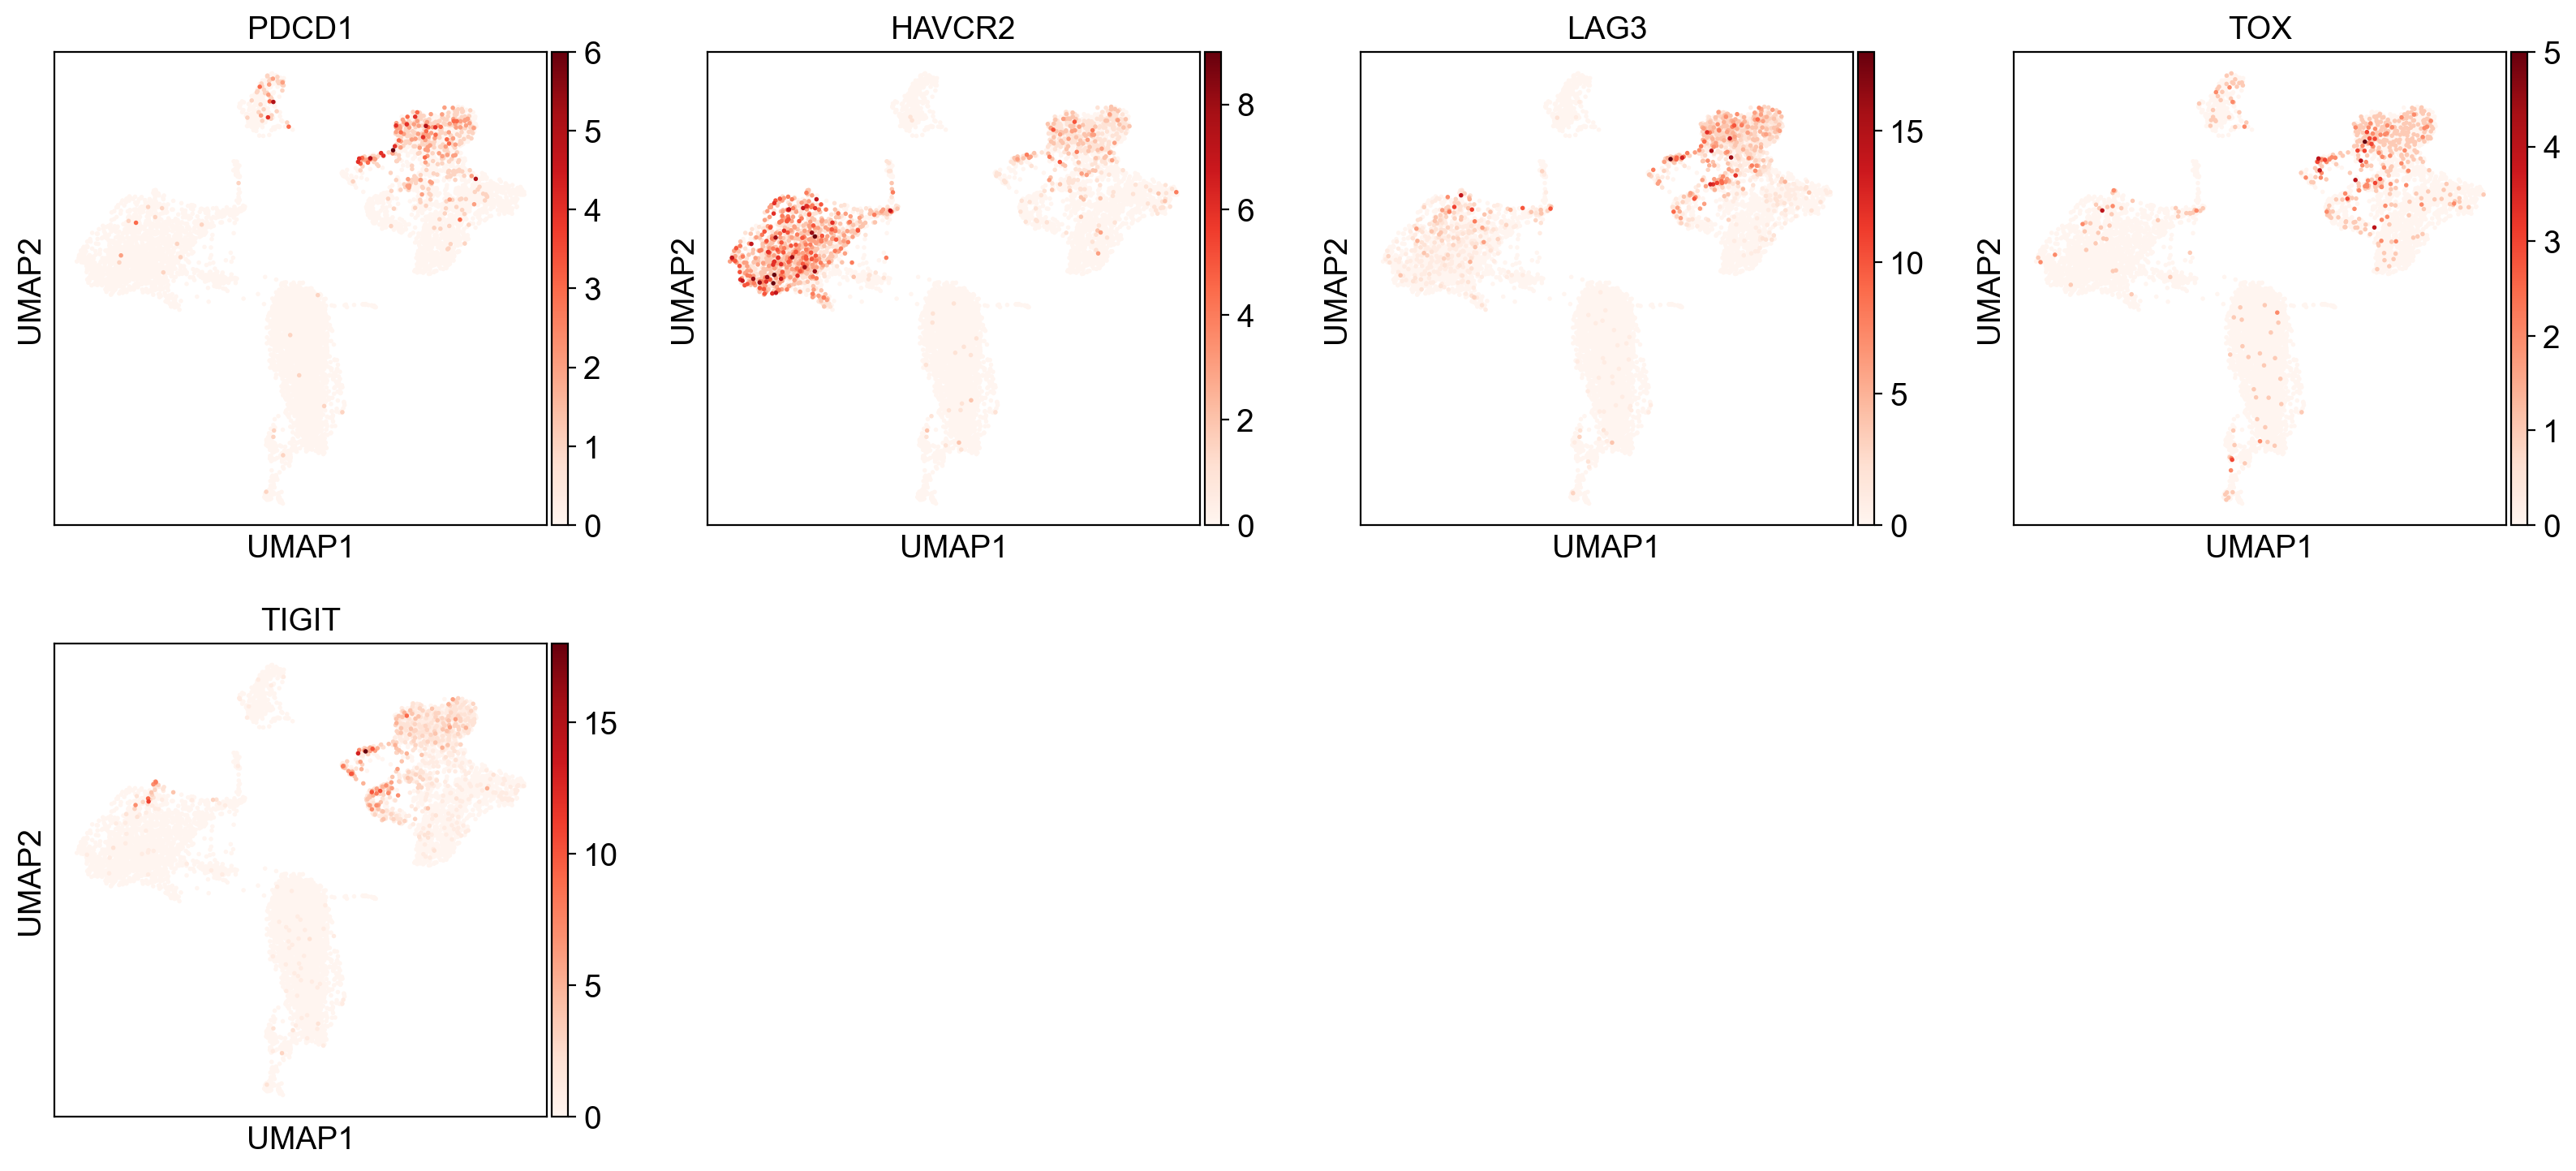

In [24]:
exhaustion_markers = ['PDCD1', 'HAVCR2', 'LAG3', 'TOX', 'TIGIT']

available_ex = [g for g in exhaustion_markers if g in adata.raw.var_names]

sc.pl.umap(adata, color=available_ex, color_map='Reds', use_raw=True)

C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_18684\463458551.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=['CD8A', 'CD163', 'TOX', 'LAG3'],


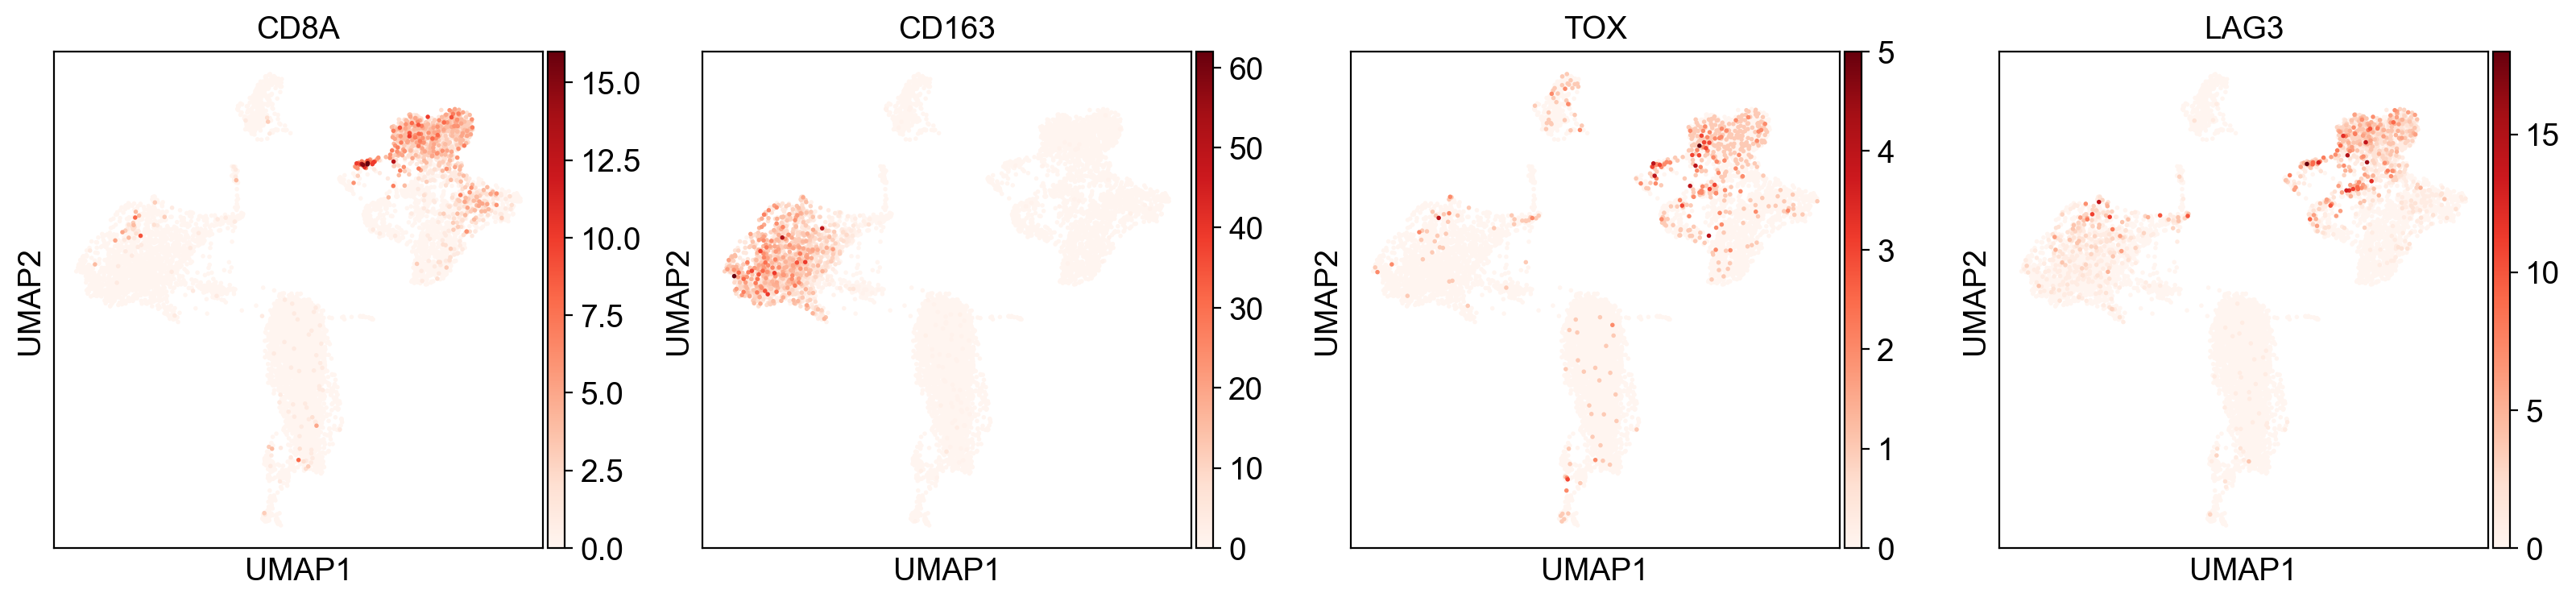

In [25]:
sc.pl.umap(adata, color=['CD8A', 'CD163', 'TOX', 'LAG3'], 
           color_map='Reds', use_raw=True, save='_key_markers.png')

adata.write('../results/sample_02_processed.h5ad')